# SNN — CIFAR-10 Adversarial Attacks
FGSM and PGD attacks on the trained SpikingCIFAR model. Same structure as the MNIST adversarial notebook.

In [2]:
!pip install snntorch -q

import gc, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import snntorch as snn
from snntorch import surrogate
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

gc.collect()
torch.cuda.empty_cache()
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'snnTorch version: {snn.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.6 MB/s eta 0:00:00
Using device: cuda
PyTorch version: 2.10.0+cu128
snnTorch version: 0.9.4


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# HYPERPARAMETERS — same as cifar-10.ipynb training notebook
# ══════════════════════════════════════════════════════════════════════════════
NUM_STEPS  = 10
BATCH_SIZE = 128
BETA       = 0.5
SLOPE      = 25

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

# ── Data — test transform only (no augmentation for evaluation) ───────────────
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
cifar_test = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Also need train set to retrain / load model
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
cifar_train = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=train_tf)
train_loader = DataLoader(cifar_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f'CIFAR-10 — Train: {len(cifar_train):,} | Test: {len(cifar_test):,}')
print(f'Classes: {CIFAR10_CLASSES}')

100%|██████████| 170M/170M [00:10<00:00, 15.9MB/s] 


CIFAR-10 — Train: 50,000 | Test: 10,000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SNN ARCHITECTURE — exact copy from cifar-10.ipynb
# ══════════════════════════════════════════════════════════════════════════════

class SpikingCIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        sg = surrogate.fast_sigmoid(slope=SLOPE)

        self.conv1 = nn.Conv2d(3,   64, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.lif1  = snn.Leaky(beta=BETA, spike_grad=sg)
        self.pool1 = nn.AvgPool2d(2)

        self.conv2 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(128)
        self.lif2  = snn.Leaky(beta=BETA, spike_grad=sg)
        self.pool2 = nn.AvgPool2d(2)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(256)
        self.lif3  = snn.Leaky(beta=BETA, spike_grad=sg)
        self.pool3 = nn.AvgPool2d(2)

        self.drop    = nn.Dropout(0.4)
        self.fc1     = nn.Linear(256*4*4, 512, bias=False)
        self.bn_fc   = nn.BatchNorm1d(512)
        self.lif4    = snn.Leaky(beta=BETA, spike_grad=sg)
        self.fc2     = nn.Linear(512, 10, bias=False)
        self.lif_out = snn.Leaky(beta=BETA, spike_grad=sg)

    def forward(self, x):
        mem1  = self.lif1.init_leaky()
        mem2  = self.lif2.init_leaky()
        mem3  = self.lif3.init_leaky()
        mem4  = self.lif4.init_leaky()
        mem_o = self.lif_out.init_leaky()
        mem_out_rec = []

        for _ in range(NUM_STEPS):
            cur1 = self.bn1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.pool1(spk1)

            cur2 = self.bn2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = self.pool2(spk2)

            cur3 = self.bn3(self.conv3(spk2))
            spk3, mem3 = self.lif3(cur3, mem3)
            spk3 = self.pool3(spk3)

            flat  = self.drop(spk3.flatten(1))
            cur4  = self.bn_fc(self.fc1(flat))
            spk4, mem4 = self.lif4(cur4, mem4)

            cur_o = self.fc2(self.drop(spk4))
            _, mem_o = self.lif_out(cur_o, mem_o)
            mem_out_rec.append(mem_o)

        return torch.stack(mem_out_rec)   # [T, B, 10]


# ── Load trained weights ──────────────────────────────────────────────────────
# Option A: load from saved checkpoint (fastest)
# Option B: retrain from scratch (uncomment the training block below)

model = SpikingCIFAR().to(device)

try:
    model.load_state_dict(torch.load('best_snn_cifar10.pth', map_location=device))
    print('Loaded weights from best_snn_cifar10.pth')
except FileNotFoundError:
    print('No checkpoint found — retraining from scratch (60 epochs)...')
    EPOCHS = 60
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
    for ep in range(1, EPOCHS + 1):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            mem_rec = model(imgs)
            loss = loss_fn(mem_rec.sum(0), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        if ep % 10 == 0:
            model.eval()
            correct = total = 0
            with torch.no_grad():
                for imgs, labels in test_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    correct += (model(imgs).sum(0).argmax(1) == labels).sum().item()
                    total += labels.size(0)
            print(f'Epoch {ep}/{EPOCHS} | Test Acc: {100*correct/total:.2f}%')
    torch.save(model.state_dict(), 'best_snn_cifar10.pth')
    print('Training done, weights saved.')

model.eval()
with torch.no_grad():
    correct = total = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).sum(0).argmax(1) == labels).sum().item()
        total += labels.size(0)
print(f'Clean Test Accuracy: {100*correct/total:.2f}%')

No checkpoint found — retraining from scratch (60 epochs)...
Epoch 10/60 | Test Acc: 57.36%
Epoch 20/60 | Test Acc: 61.52%
Epoch 30/60 | Test Acc: 64.45%
Epoch 40/60 | Test Acc: 67.66%
Epoch 50/60 | Test Acc: 68.62%
Epoch 60/60 | Test Acc: 69.71%
Training done, weights saved.
Clean Test Accuracy: 69.71%


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# ATTACK FUNCTIONS
# CIFAR-10 note: images are normalized, NOT in [0,1]
# Clamp must use per-channel normalized bounds, not (0,1)
# We compute per-channel min/max from the normalization stats
# ══════════════════════════════════════════════════════════════════════════════

# Normalized pixel bounds for CIFAR-10
# original [0,1] → normalized: (x - mean) / std
# min = (0 - mean) / std,  max = (1 - mean) / std
_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1).to(device)
_std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1).to(device)
_lb   = (0.0 - _mean) / _std   # lower bound in normalized space
_ub   = (1.0 - _mean) / _std   # upper bound in normalized space

def clamp_normalized(x):
    """Clamp normalized CIFAR image to valid pixel range."""
    return torch.max(torch.min(x, _ub), _lb)


def fgsm_attack(model, image, labels, epsilon):
    """Fast Gradient Sign Method for SNN CIFAR-10."""
    adv_image = image.clone().detach().to(device)
    adv_image.requires_grad = True

    # SNN forward: same image fed at every timestep (direct encoding)
    mem_rec = model(adv_image)            # [T, B, 10]
    output  = mem_rec.sum(dim=0)          # [B, 10]

    loss = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()

    with torch.no_grad():
        adv_image = adv_image + epsilon * adv_image.grad.sign()
        adv_image = clamp_normalized(adv_image)

    return adv_image.detach()


def pgd_attack(model, image, labels, epsilon, alpha=0.01, iters=10):
    """Projected Gradient Descent for SNN CIFAR-10."""
    original_image = image.clone().detach().to(device)

    # Random start within epsilon-ball
    adv_image = image.clone().detach() + torch.empty_like(image).uniform_(-epsilon, epsilon)
    adv_image = clamp_normalized(adv_image).detach()

    for _ in range(iters):
        adv_image.requires_grad = True

        mem_rec = model(adv_image)
        output  = mem_rec.sum(dim=0)
        loss    = F.cross_entropy(output, labels)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            adv_image = adv_image + alpha * adv_image.grad.sign()
            eta       = torch.clamp(adv_image - original_image, min=-epsilon, max=epsilon)
            adv_image = clamp_normalized(original_image + eta)

        adv_image = adv_image.detach()

    return adv_image


print('FGSM and PGD Attack functions defined.')

FGSM and PGD Attack functions defined.


Running adversarial evaluation ...
Eps: 0.000 | FGSM: 70.3% | PGD: 70.3%
Eps: 0.010 | FGSM: 59.6% | PGD: 54.8%
Eps: 0.020 | FGSM: 53.1% | PGD: 43.9%
Eps: 0.050 | FGSM: 36.5% | PGD: 22.4%
Eps: 0.100 | FGSM: 24.6% | PGD: 6.3%


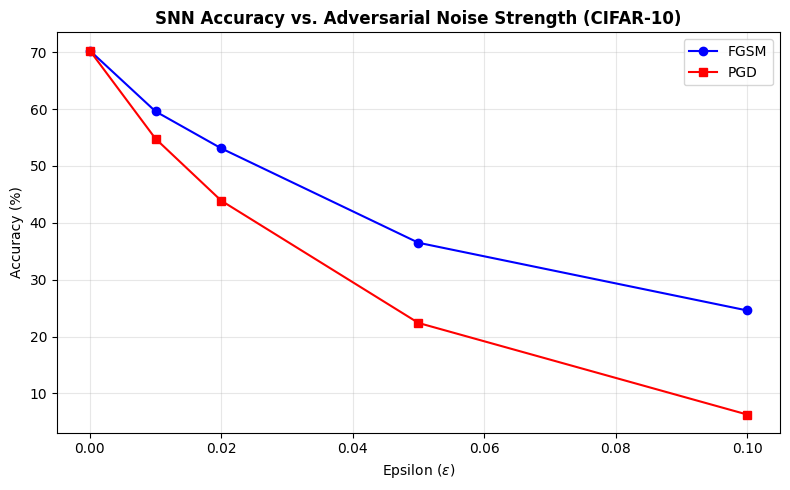

Figure saved: snn_cifar10_robustness_curve.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EPSILON SWEEP
# CIFAR-10 uses smaller epsilons than MNIST — pixel range is similar but
# images are more complex: [0, 0.01, 0.02, 0.05, 0.1] is a typical range
# ══════════════════════════════════════════════════════════════════════════════

epsilons     = [0, 0.01, 0.02, 0.05, 0.1]
fgsm_accs, pgd_accs = [], []

subset_loader = DataLoader(
    torch.utils.data.Subset(cifar_test, range(1000)), batch_size=64)

print('Running adversarial evaluation ...')
for eps in epsilons:
    f_correct, p_correct, total = 0, 0, 0
    for imgs, labels in subset_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        adv_fgsm = fgsm_attack(model, imgs, labels, eps)
        adv_pgd  = pgd_attack(model, imgs, labels, eps, alpha=eps/4 if eps > 0 else 0.01, iters=10)

        with torch.no_grad():
            f_correct += (model(adv_fgsm).sum(0).argmax(1) == labels).sum().item()
            p_correct += (model(adv_pgd ).sum(0).argmax(1) == labels).sum().item()
            total     += labels.size(0)

    fgsm_accs.append(100. * f_correct / total)
    pgd_accs.append(100. * p_correct / total)
    print(f'Eps: {eps:.3f} | FGSM: {fgsm_accs[-1]:.1f}% | PGD: {pgd_accs[-1]:.1f}%')

plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accs, 'o-', label='FGSM', color='blue')
plt.plot(epsilons, pgd_accs,  's-', label='PGD',  color='red')
plt.title('SNN Accuracy vs. Adversarial Noise Strength (CIFAR-10)', fontweight='bold')
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('snn_cifar10_robustness_curve.png', bbox_inches='tight')
plt.show()
print('Figure saved: snn_cifar10_robustness_curve.png')

Generating Comprehensive Statistical Analysis (Epsilon: 0.02)...


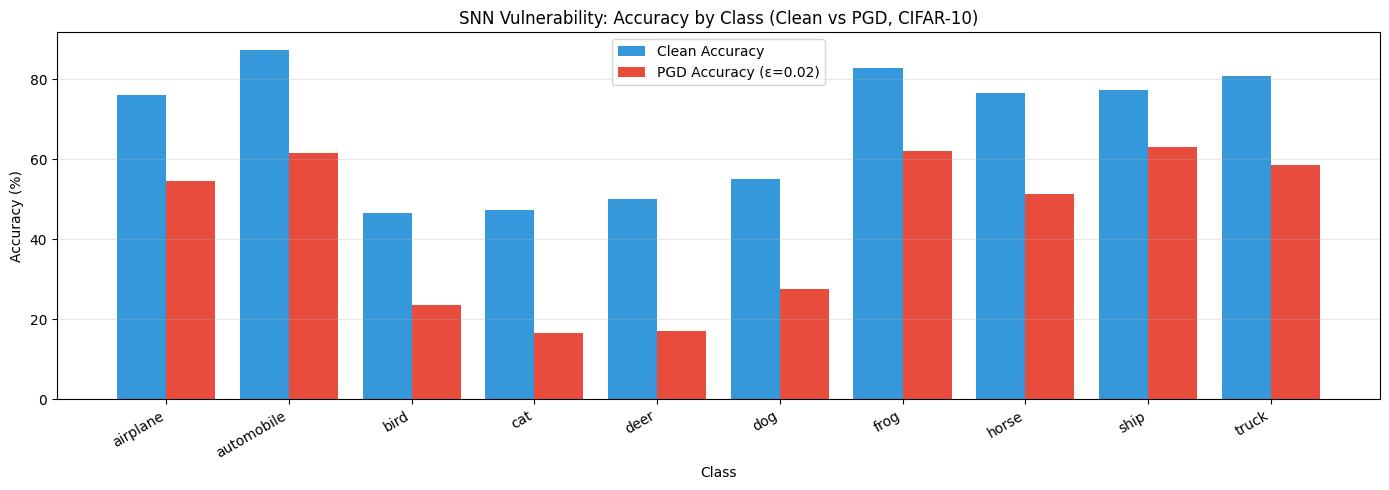

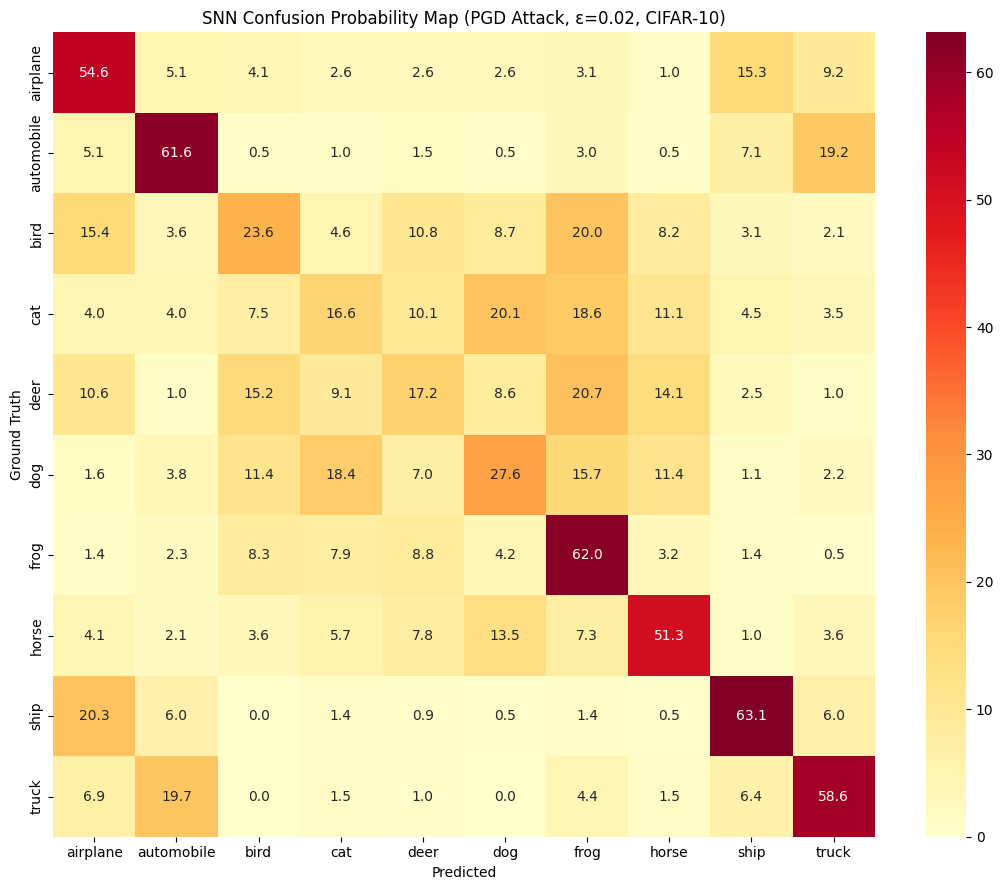


--- TOP 5 ADVERSARIAL MISCLASSIFICATIONS ---
        ship → airplane    : 20.3% (44 instances)
        deer → frog        : 20.7% (41 instances)
       truck → automobile  : 19.7% (40 instances)
         cat → dog         : 20.1% (40 instances)
        bird → frog        : 20.0% (39 instances)


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE STATISTICAL ANALYSIS
# 2000 samples | class-wise bar chart | confusion heatmap | top-5 transitions
# ══════════════════════════════════════════════════════════════════════════════

def perform_final_analysis(model, dataset, epsilon, device, model_name='SNN'):
    model.eval()
    y_true, y_pred_clean, y_pred_adv = [], [], []

    print(f'Generating Comprehensive Statistical Analysis (Epsilon: {epsilon})...')

    analysis_loader = DataLoader(
        torch.utils.data.Subset(dataset, range(min(2000, len(dataset)))), batch_size=64)

    for imgs, labels in analysis_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            y_pred_clean.extend(model(imgs).sum(0).argmax(1).cpu().numpy())

        adv_imgs = pgd_attack(model, imgs, labels, epsilon,
                              alpha=epsilon/4 if epsilon > 0 else 0.01, iters=10)
        with torch.no_grad():
            y_pred_adv.extend(model(adv_imgs).sum(0).argmax(1).cpu().numpy())

        y_true.extend(labels.cpu().numpy())

    y_true = np.array(y_true)

    # --- 1. Class-wise Accuracy Bar Chart ---
    cm_clean = confusion_matrix(y_true, y_pred_clean, labels=range(10))
    cm_adv   = confusion_matrix(y_true, y_pred_adv,   labels=range(10))
    acc_clean = cm_clean.diagonal() / (cm_clean.sum(axis=1) + 1e-10) * 100
    acc_adv   = cm_adv.diagonal()   / (cm_adv.sum(axis=1)   + 1e-10) * 100

    plt.figure(figsize=(14, 5))
    x = np.arange(10)
    plt.bar(x - 0.2, acc_clean, 0.4, label='Clean Accuracy',              color='#3498db')
    plt.bar(x + 0.2, acc_adv,   0.4, label=f'PGD Accuracy (ε={epsilon})', color='#e74c3c')
    plt.xlabel('Class')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{model_name} Vulnerability: Accuracy by Class (Clean vs PGD, CIFAR-10)')
    plt.xticks(x, CIFAR10_CLASSES, rotation=30, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'snn_cifar10_classwise.png', bbox_inches='tight')
    plt.show()

    # --- 2. Confusion Probability Heatmap ---
    plt.figure(figsize=(11, 9))
    cm_perc = cm_adv.astype('float') / (cm_adv.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
    plt.title(f'{model_name} Confusion Probability Map (PGD Attack, ε={epsilon}, CIFAR-10)')
    plt.ylabel('Ground Truth')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'snn_cifar10_confusion.png', bbox_inches='tight')
    plt.show()

    # --- 3. Top 5 Adversarial Transitions ---
    errors = pd.DataFrame({'True': y_true, 'Pred': y_pred_adv})
    errors = errors[errors['True'] != errors['Pred']]
    top_confusions = errors.groupby(['True', 'Pred']).size().sort_values(ascending=False).head(5)
    print(f'\n--- TOP 5 ADVERSARIAL MISCLASSIFICATIONS ---')
    for (t, p), count in top_confusions.items():
        prob = (count / (y_true == t).sum()) * 100
        print(f"{CIFAR10_CLASSES[t]:>12} → {CIFAR10_CLASSES[p]:<12}: {prob:.1f}% ({count} instances)")


perform_final_analysis(model, cifar_test, epsilon=0.02, device=device, model_name='SNN')

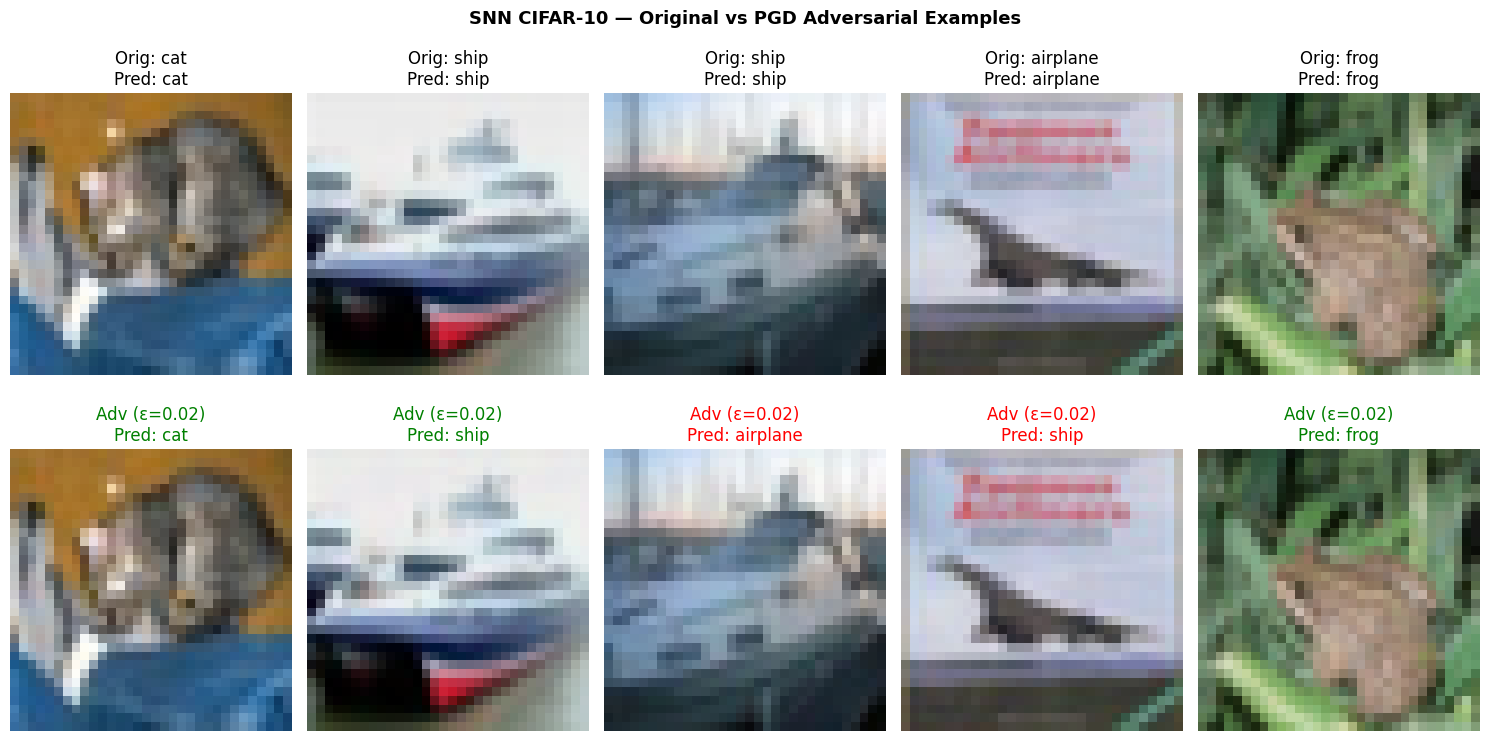

Figure saved: snn_cifar10_adv_samples.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# ADVERSARIAL SAMPLE VISUALIZATION
# CIFAR-10: images are 3-channel normalized — need denormalize before display
# ══════════════════════════════════════════════════════════════════════════════

def denormalize(tensor):
    """Convert normalized CIFAR-10 tensor back to [0,1] for display."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)


def visualize_adversarial_samples(model, loader, epsilon, device):
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)

    adv_imgs = pgd_attack(model, imgs, labels, epsilon,
                          alpha=epsilon/4 if epsilon > 0 else 0.01, iters=15)

    with torch.no_grad():
        clean_preds = model(imgs).sum(0).argmax(1)
        adv_preds   = model(adv_imgs).sum(0).argmax(1)

    plt.figure(figsize=(15, 8))
    for i in range(5):
        # Original
        plt.subplot(2, 5, i + 1)
        plt.imshow(denormalize(imgs[i]).permute(1, 2, 0))
        plt.title(f'Orig: {CIFAR10_CLASSES[labels[i]]}\nPred: {CIFAR10_CLASSES[clean_preds[i]]}')
        plt.axis('off')

        # Adversarial
        plt.subplot(2, 5, i + 6)
        plt.imshow(denormalize(adv_imgs[i]).permute(1, 2, 0))
        color = 'red' if adv_preds[i] != labels[i] else 'green'
        plt.title(f'Adv (ε={epsilon})\nPred: {CIFAR10_CLASSES[adv_preds[i]]}', color=color)
        plt.axis('off')

    plt.suptitle('SNN CIFAR-10 — Original vs PGD Adversarial Examples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('snn_cifar10_adv_samples.png', bbox_inches='tight')
    plt.show()
    print('Figure saved: snn_cifar10_adv_samples.png')


visualize_adversarial_samples(model, test_loader, epsilon=0.02, device=device)